# Image Sentiment & Emotion Training Notebook
This notebook downloads the **FER-2013** dataset (Facial Emotion Recognition) from Hugging Face, saves a subset of images locally under the `data/fer2013` directory (organized by sentiment category folders), applies image preprocessing and augmentation transforms, and trains the **ImageCNN** model defined in `models.py` on Apple Silicon GPU (`mps` device).

## Setup & Imports

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Append current directory to path to import local modules
# Append robust search paths for local modules to support different launch directories
for p in ['.', '..', 'ml-training', '../ml-training']:
    path_to_add = os.path.abspath(p)
    if path_to_add not in sys.path:
        sys.path.append(path_to_add)
from models import ImageCNN

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f"Using device: {device}")

Using device: mps


## 1. Download and Save Dataset Locally
We download the `AutumnQiu/fer2013` dataset and write a subset of images locally under the `data/fer2013/` directory. We map the facial emotion labels to sentiment subdirectories:
- **Negative (0)**: `0` (Angry), `1` (Disgust), `2` (Fear), `4` (Sad)
- **Neutral (1)**: `5` (Surprise), `6` (Neutral)
- **Positive (2)**: `3` (Happy)

In [2]:
from datasets import load_dataset

print("Loading fer2013 dataset from Hugging Face...")
raw_dataset = load_dataset("AutumnQiu/fer2013")

base_data_dir = "data/fer2013"
os.makedirs(base_data_dir, exist_ok=True)

# Sentiment Mapping
sentiment_mapping = {
    0: 0, # Angry -> Neg
    1: 0, # Disgust -> Neg
    2: 0, # Fear -> Neg
    3: 2, # Happy -> Pos
    4: 0, # Sad -> Neg
    5: 1, # Surprise -> Neu
    6: 1  # Neutral -> Neu
}

def save_split_images(split_name, max_samples=3000):
    print(f"Saving images from {split_name} split...")
    split_data = raw_dataset[split_name]
    count = 0
    
    for i, item in enumerate(split_data):
        if count >= max_samples:
            break
            
        label_code = item['label']
        sentiment_label = sentiment_mapping.get(label_code, 1)
        img = item['image']
        
        # Directory for this sentiment class inside this split
        class_dir = os.path.join(base_data_dir, split_name, str(sentiment_label))
        os.makedirs(class_dir, exist_ok=True)
        
        img_path = os.path.join(class_dir, f"img_{i}.png")
        img.save(img_path)
        count += 1
        
    print(f"Saved {count} images to {os.path.join(base_data_dir, split_name)}")

# Save subsets of train, valid, and test sets
save_split_images('train', max_samples=4000)
save_split_images('valid', max_samples=1000)
save_split_images('test', max_samples=1000)

print("Image dataset saved locally successfully!")

/Users/sumitkumar776693/Desktop/Project/Client/Sentimental-Analyses-Current/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading fer2013 dataset from Hugging Face...


Saving images from train split...
Saved 4000 images to data/fer2013/train
Saving images from valid split...
Saved 1000 images to data/fer2013/valid
Saving images from test split...
Saved 1000 images to data/fer2013/test
Image dataset saved locally successfully!


## 2. Image Preprocessing & Transforms
We scale the images to `(128, 128)` and apply normalization so they match the input layer of `ImageCNN`.

In [3]:
# Preprocessing and data augmentations
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load using ImageFolder
train_dir = os.path.join(base_data_dir, 'train')
val_dir = os.path.join(base_data_dir, 'valid')
test_dir = os.path.join(base_data_dir, 'test')

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Loaded datasets: Train={len(train_dataset)}, Validation={len(val_dataset)}, Test={len(test_dataset)}")

Loaded datasets: Train=4000, Validation=1000, Test=1000


## 3. Train ImageCNN Model
We train the model for 10 epochs using Adam optimizer and Cross Entropy loss.

In [4]:
model = ImageCNN(feature_dim=256).to(device)
eval_classifier = nn.Linear(256, 3).to(device) # maps to 3 classes (0: Neg, 1: Neu, 2: Pos)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(list(model.parameters()) + list(eval_classifier.parameters()), lr=0.001)

epochs = 10
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("=== Training ImageCNN model ===")
for epoch in range(epochs):
    model.train()
    eval_classifier.train()
    train_loss, correct, total = 0.0, 0, 0
    
    for batch_inputs, batch_labels in train_loader:
        batch_inputs, batch_labels = batch_inputs.to(device), batch_labels.to(device)
        
        optimizer.zero_grad()
        features = model(batch_inputs)
        logits = eval_classifier(features)
        loss = criterion(logits, batch_labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * batch_inputs.size(0)
        _, predicted = logits.max(1)
        total += batch_labels.size(0)
        correct += predicted.eq(batch_labels).sum().item()
        
    epoch_loss = train_loss / total
    epoch_acc = correct / total
    
    # Validation
    model.eval()
    eval_classifier.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for batch_inputs, batch_labels in val_loader:
            batch_inputs, batch_labels = batch_inputs.to(device), batch_labels.to(device)
            features = model(batch_inputs)
            logits = eval_classifier(features)
            loss = criterion(logits, batch_labels)
            
            val_loss += loss.item() * batch_inputs.size(0)
            _, predicted = logits.max(1)
            val_total += batch_labels.size(0)
            val_correct += predicted.eq(batch_labels).sum().item()
            
    val_epoch_loss = val_loss / val_total
    val_epoch_acc = val_correct / val_total
    
    history['train_loss'].append(epoch_loss)
    history['val_loss'].append(val_epoch_loss)
    history['train_acc'].append(epoch_acc)
    history['val_acc'].append(val_epoch_acc)
    
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f} | Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}")

=== Training ImageCNN model ===
Epoch 1/10 - Train Loss: 0.9437, Train Acc: 0.5765 | Val Loss: 0.8115, Val Acc: 0.6380
Epoch 2/10 - Train Loss: 0.7513, Train Acc: 0.6675 | Val Loss: 0.7823, Val Acc: 0.6630
Epoch 3/10 - Train Loss: 0.7113, Train Acc: 0.6897 | Val Loss: 0.7450, Val Acc: 0.6620
Epoch 4/10 - Train Loss: 0.6692, Train Acc: 0.7145 | Val Loss: 0.6978, Val Acc: 0.6860
Epoch 5/10 - Train Loss: 0.6399, Train Acc: 0.7250 | Val Loss: 0.6852, Val Acc: 0.7300
Epoch 6/10 - Train Loss: 0.6086, Train Acc: 0.7480 | Val Loss: 0.7781, Val Acc: 0.6620
Epoch 7/10 - Train Loss: 0.5858, Train Acc: 0.7515 | Val Loss: 0.6678, Val Acc: 0.7240
Epoch 8/10 - Train Loss: 0.5520, Train Acc: 0.7652 | Val Loss: 0.7107, Val Acc: 0.6920
Epoch 9/10 - Train Loss: 0.5375, Train Acc: 0.7758 | Val Loss: 0.7046, Val Acc: 0.7150
Epoch 10/10 - Train Loss: 0.5191, Train Acc: 0.7890 | Val Loss: 0.7970, Val Acc: 0.7120


## 4. Metrics & Evaluation

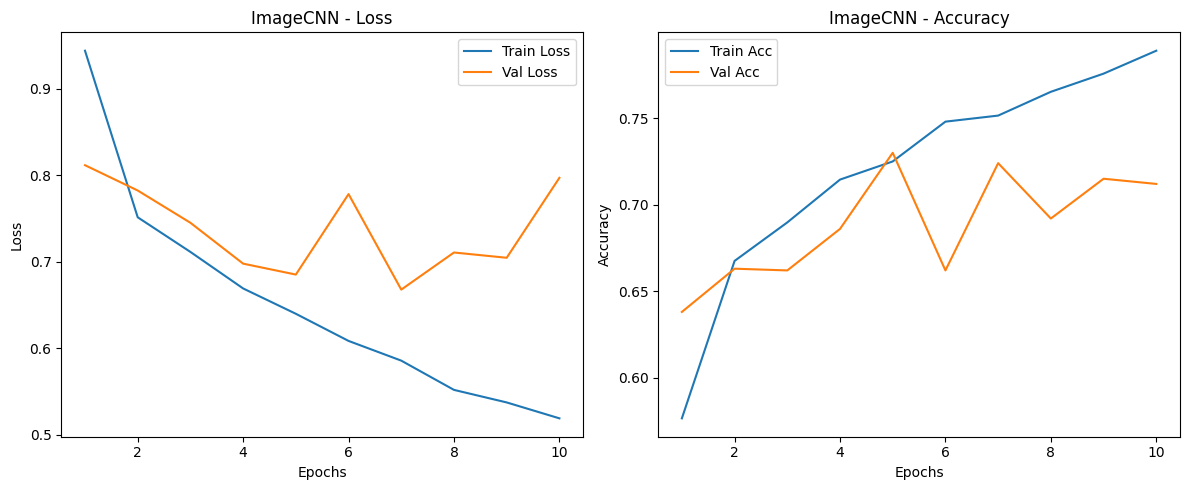

=== ImageCNN test performance ===
              precision    recall  f1-score   support

    Negative       0.65      0.79      0.71       446
     Neutral       0.60      0.60      0.60       297
    Positive       0.93      0.58      0.72       257

    accuracy                           0.68      1000
   macro avg       0.73      0.66      0.68      1000
weighted avg       0.71      0.68      0.68      1000



In [5]:
# Plot validation curves
epochs_range = range(1, epochs + 1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss')
plt.plot(epochs_range, history['val_loss'], label='Val Loss')
plt.title('ImageCNN - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Train Acc')
plt.plot(epochs_range, history['val_acc'], label='Val Acc')
plt.title('ImageCNN - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Final test set report
model.eval()
eval_classifier.eval()
preds = []
targets = []
with torch.no_grad():
    for batch_inputs, batch_labels in test_loader:
        batch_inputs = batch_inputs.to(device)
        features = model(batch_inputs)
        logits = eval_classifier(features)
        _, predicted = logits.max(1)
        preds.extend(predicted.cpu().numpy())
        targets.extend(batch_labels.numpy())

print("=== ImageCNN test performance ===")
print(classification_report(targets, preds, target_names=['Negative', 'Neutral', 'Positive']))

## 5. Save Model Weights

In [6]:
os.makedirs('../weights', exist_ok=True)
weight_path = '../weights/image_model.pt'
torch.save(model.state_dict(), weight_path)
print(f"Successfully saved image model weights to {weight_path}")

Successfully saved image model weights to ../weights/image_model.pt
